## 1. CARGA DE DATOS

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import random
warnings.filterwarnings('ignore')

# Establecer semilla para reproducibilidad
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
print(f'✓ Semilla global establecida: {SEED}')

DATASET_CSV = 'dataset-uci.csv'
print('Ruta de trabajo:', os.getcwd())

df = pd.read_csv(DATASET_CSV, sep=';', header=0)
print(f'✓ Lectura exitosa — forma: {df.shape}')

# Verificar valores nulos
print('\n' + '='*60)
print('VERIFICACIÓN DE VALORES NULOS')
print('='*60)
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje': porcentaje_nulos})
df_nulos = df_nulos[df_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(df_nulos) > 0:
    print(f'\n⚠ Se encontraron {len(df_nulos)} columnas con valores nulos:')
    display(df_nulos)
    
    # Visualización de nulos
    plt.figure(figsize=(12, 6))
    plt.barh(df_nulos.index, df_nulos['Porcentaje'], color='#e74c3c')
    plt.xlabel('Porcentaje de valores nulos (%)')
    plt.title('Distribución de Valores Nulos por Feature', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No se encontraron valores nulos en el dataset')

print('='*60)

display(df.head())
df.info()

✓ Semilla global establecida: 40
Ruta de trabajo: c:\Users\USER\Downloads\ML_ProyectoFinal
✓ Lectura exitosa — forma: (319, 39)

VERIFICACIÓN DE VALORES NULOS
✅ No se encontraron valores nulos en el dataset


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

## 2. ANÁLISIS EXPLORATORIO RÁPIDO

Distribución de clases:
Gallstone Status
0    161
1    158
Name: count, dtype: int64


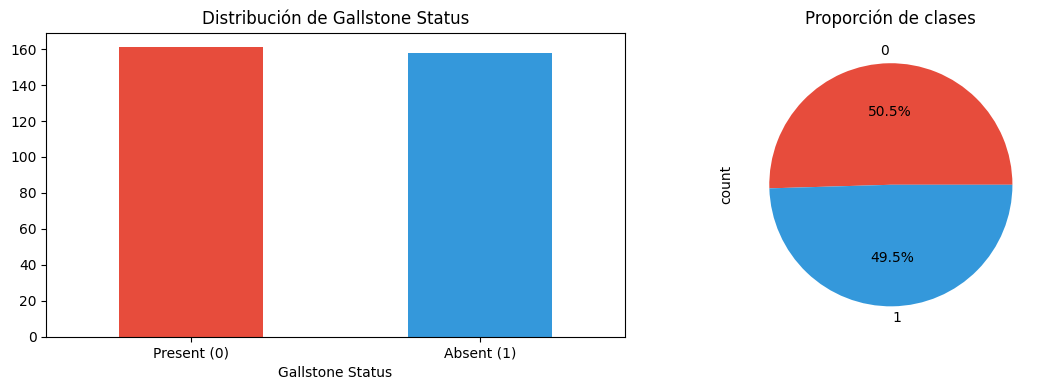

In [2]:
# Distribución de la variable objetivo
target_col = 'Gallstone Status'
print("Distribución de clases:")
print(df[target_col].value_counts())

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#3498db'])
ax[0].set_title('Distribución de Gallstone Status')
ax[0].set_xticklabels(['Present (0)', 'Absent (1)'], rotation=0)

df[target_col].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#e74c3c', '#3498db'])
ax[1].set_title('Proporción de clases')
plt.tight_layout()
plt.show()

Top 10 variables correlacionadas con 'Gallstone Status':
Gallstone Status                                  1.000000
Vitamin D                                         0.354873
C-Reactive Protein (CRP)                          0.281995
Lean Mass (LM) (%)                                0.225749
Total Body Fat Ratio (TBFR) (%)                   0.225470
Bone Mass (BM)                                    0.216570
Hemoglobin (HGB)                                  0.196872
Extracellular Water (ECW)                         0.178436
Total Fat Content (TFC)                           0.170158
Extracellular Fluid/Total Body Water (ECF/TBW)    0.169826
Hyperlipidemia                                    0.161901
Name: Gallstone Status, dtype: float64

MATRIZ DE CORRELACIÓN COMPLETA


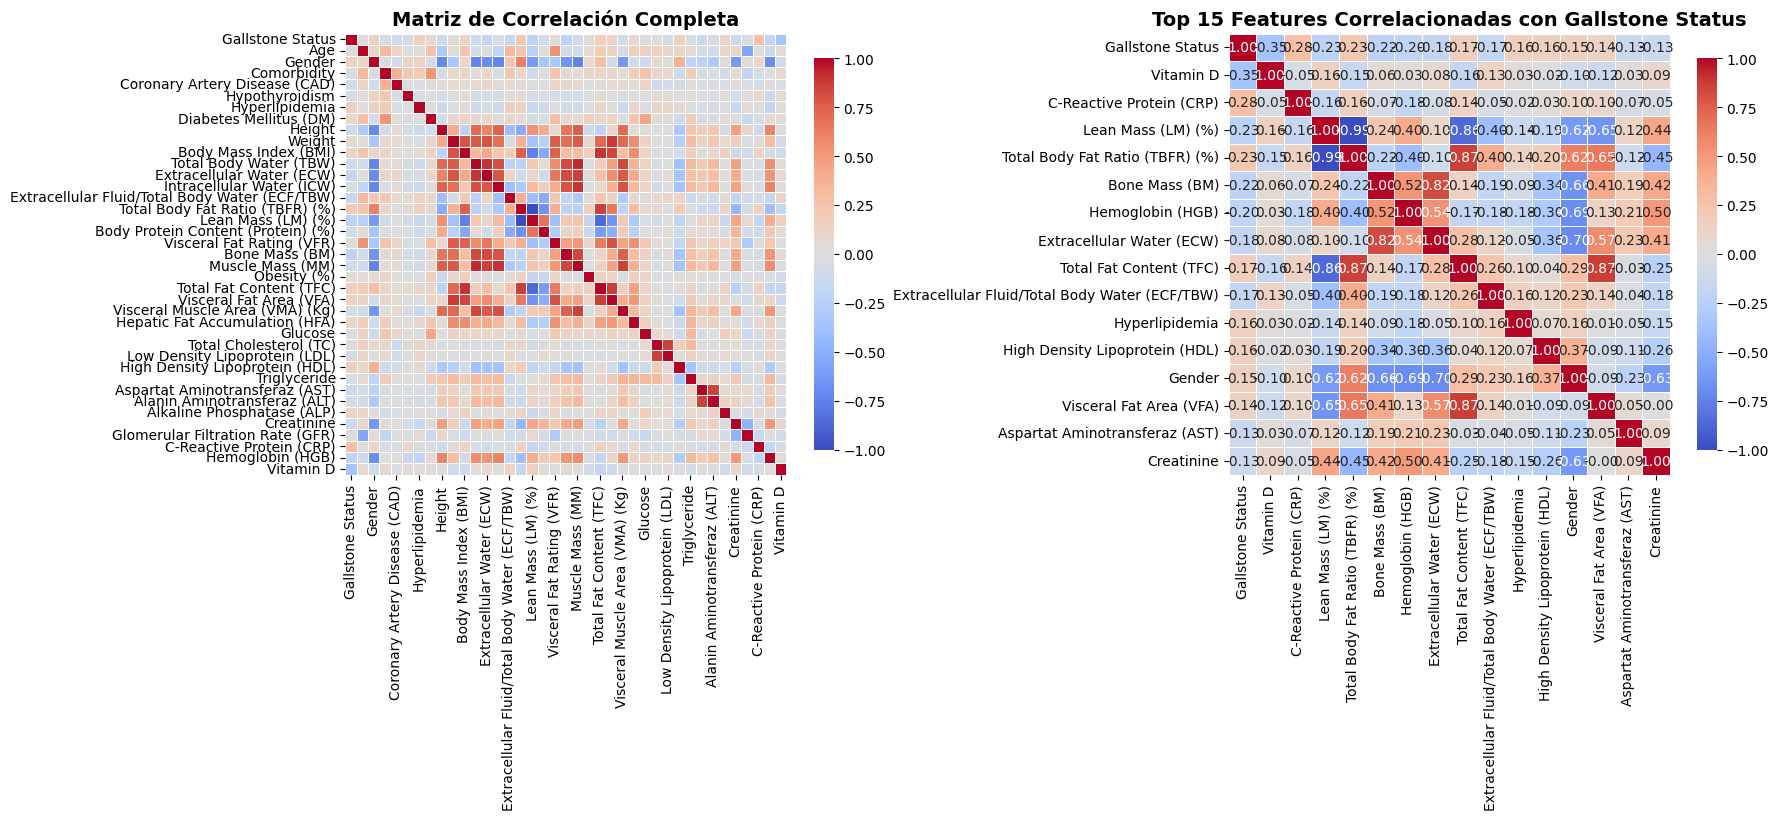

In [3]:
# Matriz de correlación (solo top features)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Correlación con target
if target_col in numeric_cols:
    target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)
    print(f"Top 10 variables correlacionadas con '{target_col}':")
    print(target_corr.head(11))
    
    # Visualización de matriz de correlación completa
    print('\n' + '='*60)
    print('MATRIZ DE CORRELACIÓN COMPLETA')
    print('='*60)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Matriz de correlación completa
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title('Matriz de Correlación Completa', fontsize=14, fontweight='bold')
    
    # Top 15 correlaciones con target
    top_features = target_corr.head(16).index  # 15 + target
    corr_top = df[top_features].corr()
    sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title(f'Top 15 Features Correlacionadas con {target_col}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 3. ELIMINACIÓN DE FEATURES REDUNDANTES

Eliminamos features con alta colinealidad (|r| > 0.8) para reducir multicolinealidad.

In [4]:
drop_cols = [
    "Visceral Fat Area (VFA)",
    "Total Fat Content (TFC)",
    "Lean Mass (LM) (%)",
    "Extracellular Water (ECW)",
    "Intracellular Water (ICW)",
    "Visceral Muscle Area (VMA) (Kg)",
    "Total Cholesterol (TC)",
    "Aspartat Aminotransferaz (AST)",
    "Total Body Water (TBW)",
    "Bone Mass (BM)"
]

drop_cols_found = [c for c in drop_cols if c in df.columns]
print(f"Eliminando {len(drop_cols_found)} features redundantes...")

df = df.drop(columns=drop_cols_found)
print(f"✓ Nueva forma: {df.shape}")

Eliminando 10 features redundantes...
✓ Nueva forma: (319, 29)


## 4. PREPROCESAMIENTO Y DIVISIÓN DE DATOS

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separar features y target
X = df.drop(columns=[target_col])
y = df[target_col]

# División estratificada: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Datos estandarizados")

Train: 223 | Val: 48 | Test: 48
✓ Datos estandarizados


## 5. DATA AUGMENTATION CON SMOTE

In [6]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"ANTES de SMOTE: {dict(Counter(y_train))}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"DESPUÉS de SMOTE: {dict(Counter(y_train_smote))}")
print(f"✓ Aumento: {len(y_train_smote) - len(y_train)} muestras sintéticas")

ANTES de SMOTE: {1: 110, 0: 113}
DESPUÉS de SMOTE: {1: 113, 0: 113}
✓ Aumento: 3 muestras sintéticas
DESPUÉS de SMOTE: {1: 113, 0: 113}
✓ Aumento: 3 muestras sintéticas


## 5.1 INGENIERÍA DE CARACTERÍSTICAS AVANZADA

Creamos interacciones entre features para capturar relaciones no lineales que pueden mejorar el rendimiento del modelo.

In [7]:
print("Creando features adicionales mediante ingeniería de características...")
print(f"Features originales: {X_train_smote.shape[1]}")

# Convertir a DataFrame para facilitar manipulación
X_train_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
X_val_df = pd.DataFrame(X_val_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# 1. Interacciones BMI con otras variables
if 'Body Mass Index (BMI)' in X_train_df.columns and 'Age' in X_train_df.columns:
    X_train_df['BMI_x_Age'] = X_train_df['Body Mass Index (BMI)'] * X_train_df['Age']
    X_val_df['BMI_x_Age'] = X_val_df['Body Mass Index (BMI)'] * X_val_df['Age']
    X_test_df['BMI_x_Age'] = X_test_df['Body Mass Index (BMI)'] * X_test_df['Age']
    print("✓ Creada: BMI × Age")

# 2. Ratios de lípidos (indicadores importantes de salud cardiovascular)
if 'High Density Lipoprotein (HDL)' in X_train_df.columns and 'Low Density Lipoprotein (LDL)' in X_train_df.columns:
    X_train_df['HDL_LDL_ratio'] = X_train_df['High Density Lipoprotein (HDL)'] / (X_train_df['Low Density Lipoprotein (LDL)'] + 1e-5)
    X_val_df['HDL_LDL_ratio'] = X_val_df['High Density Lipoprotein (HDL)'] / (X_val_df['Low Density Lipoprotein (LDL)'] + 1e-5)
    X_test_df['HDL_LDL_ratio'] = X_test_df['High Density Lipoprotein (HDL)'] / (X_test_df['Low Density Lipoprotein (LDL)'] + 1e-5)
    print("✓ Creada: HDL/LDL ratio")

# 3. Índice de masa grasa
if 'Body Mass Index (BMI)' in X_train_df.columns and 'Skeletal Muscle Mass (SMM)' in X_train_df.columns:
    X_train_df['Fat_Index'] = X_train_df['Body Mass Index (BMI)'] / (X_train_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
    X_val_df['Fat_Index'] = X_val_df['Body Mass Index (BMI)'] / (X_val_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
    X_test_df['Fat_Index'] = X_test_df['Body Mass Index (BMI)'] / (X_test_df['Skeletal Muscle Mass (SMM)'] + 1e-5)
    print("✓ Creada: Fat Index (BMI/SMM)")

# 4. Edad cuadrática (captura efectos no lineales de la edad)
if 'Age' in X_train_df.columns:
    X_train_df['Age_squared'] = X_train_df['Age'] ** 2
    X_val_df['Age_squared'] = X_val_df['Age'] ** 2
    X_test_df['Age_squared'] = X_test_df['Age'] ** 2
    print("✓ Creada: Age²")

# 5. Interacción Triglicéridos con Lípidos
if 'Triglyceride (TG)' in X_train_df.columns and 'High Density Lipoprotein (HDL)' in X_train_df.columns:
    X_train_df['TG_HDL_ratio'] = X_train_df['Triglyceride (TG)'] / (X_train_df['High Density Lipoprotein (HDL)'] + 1e-5)
    X_val_df['TG_HDL_ratio'] = X_val_df['Triglyceride (TG)'] / (X_val_df['High Density Lipoprotein (HDL)'] + 1e-5)
    X_test_df['TG_HDL_ratio'] = X_test_df['Triglyceride (TG)'] / (X_test_df['High Density Lipoprotein (HDL)'] + 1e-5)
    print("✓ Creada: TG/HDL ratio")

# 6. Enzimas hepáticas combinadas
if 'Alanine Aminotransferase (ALT)' in X_train_df.columns and 'Gamma-glutamyltransferase (GGT)' in X_train_df.columns:
    X_train_df['Liver_Enzyme_Index'] = X_train_df['Alanine Aminotransferase (ALT)'] * X_train_df['Gamma-glutamyltransferase (GGT)']
    X_val_df['Liver_Enzyme_Index'] = X_val_df['Alanine Aminotransferase (ALT)'] * X_val_df['Gamma-glutamyltransferase (GGT)']
    X_test_df['Liver_Enzyme_Index'] = X_test_df['Alanine Aminotransferase (ALT)'] * X_test_df['Gamma-glutamyltransferase (GGT)']
    print("✓ Creada: Liver Enzyme Index (ALT×GGT)")

# Re-estandarizar las nuevas features
from sklearn.preprocessing import StandardScaler
scaler_features = StandardScaler()

X_train_smote = scaler_features.fit_transform(X_train_df)
X_val_scaled = scaler_features.transform(X_val_df)
X_test_scaled = scaler_features.transform(X_test_df)

print(f"\n✓ Features finales: {X_train_smote.shape[1]}")
print(f"✓ Incremento: +{X_train_smote.shape[1] - len(X_train.columns)} features")

Creando features adicionales mediante ingeniería de características...
Features originales: 28
✓ Creada: BMI × Age
✓ Creada: HDL/LDL ratio
✓ Creada: Age²

✓ Features finales: 31
✓ Incremento: +3 features


## 6. CONFIGURACIÓN DE PYTORCH

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

# Configurar semillas de PyTorch para reproducibilidad
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"✓ Semillas PyTorch establecidas: {SEED}")

# Convertir a tensores (con SMOTE para train)
X_train_tensor = torch.FloatTensor(X_train_smote)
y_train_tensor = torch.LongTensor(y_train_smote)

X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.LongTensor(y_val.values)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test.values)

input_dim = X_train_tensor.shape[1]
num_classes = len(torch.unique(y_train_tensor))

print(f"Input features: {input_dim} | Classes: {num_classes}")

Device: cuda
✓ Semillas PyTorch establecidas: 40
Input features: 31 | Classes: 2


## 7. ARQUITECTURA DEL MODELO MLP

In [9]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], num_classes=2, dropout=0.5, activation='relu'):
        super(MLPClassifier, self).__init__()
        
        # Seleccionar función de activación
        activation_map = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU(),
            'gelu': nn.GELU()
        }
        act_fn = activation_map.get(activation, nn.ReLU())
        self.activation_name = activation
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            linear = nn.Linear(prev_dim, hidden_dim)
            # Inicialización He/Kaiming para ReLU, Xavier para otras
            if activation in ['relu', 'leaky_relu']:
                nn.init.kaiming_normal_(linear.weight, mode='fan_in', nonlinearity='relu')
            else:
                nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            
            layers.append(linear)
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(act_fn)
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        # Capa final con inicialización Xavier
        final_layer = nn.Linear(prev_dim, num_classes)
        nn.init.xavier_normal_(final_layer.weight)
        nn.init.zeros_(final_layer.bias)
        layers.append(final_layer)
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

print("✓ Arquitectura MLP mejorada definida (soporta múltiples activaciones)")        

✓ Arquitectura MLP mejorada definida (soporta múltiples activaciones)


## 8. FUNCIÓN DE ENTRENAMIENTO

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs=100, patience=10, model_name='model', scheduler=None, grad_clip=1.0):
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0
    best_epoch = 0
    
    print(f"\n{'='*80}")
    print(f"ENTRENAMIENTO: {model_name.upper()}")
    print(f"{'='*80}")
    print(f"Configuración:")
    print(f"  Épocas máximas: {num_epochs}")
    print(f"  Patience: {patience}")
    print(f"  Optimizer: {optimizer.__class__.__name__}")
    print(f"  Learning rate inicial: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"  Weight decay: {optimizer.param_groups[0]['weight_decay']:.6f}")
    print(f"  Gradient clipping: {grad_clip}")
    print(f"  Scheduler: {scheduler.__class__.__name__ if scheduler else 'None'}")
    print(f"{'='*80}\n")
    
    # Entrenamiento épocas
    for epoch in range(num_epochs):
        # Training con barra de progreso por época
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []
        
        train_pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs} [Train]', 
                         leave=True, unit='batch', position=0)
        
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
            
            # Actualizar barra con loss actual
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')
        
        # Validation con barra de progreso
        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []
        
        val_pbar = tqdm(val_loader, desc=f'Época {epoch+1}/{num_epochs} [Val]', 
                       leave=True, unit='batch', position=0)
        
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='weighted')
        
        # Scheduler
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        # Imprimir resumen de época
        gap = abs(val_loss - train_loss)
        print(f"\nÉpoca {epoch+1}/{num_epochs} - "
              f"TrLoss: {train_loss:.4f} | ValLoss: {val_loss:.4f} | Gap: {gap:.4f} | "
              f"TrAcc: {train_acc:.3f} | ValAcc: {val_acc:.3f} | "
              f"TrF1: {train_f1:.3f} | ValF1: {val_f1:.3f} | LR: {current_lr:.1e}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"  ⭐ MEJOR MODELO guardado (ValLoss={val_loss:.4f}, ValAcc={val_acc:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n{'='*80}")
                print(f"⚠ EARLY STOPPING en época {epoch+1} (sin mejora por {patience} épocas)")
                print(f"{'='*80}")
                break
    
    model.load_state_dict(torch.load(f'{model_name}_best.pth'))
    
    print(f"\n{'='*80}")
    print(f"RESUMEN DEL ENTRENAMIENTO")
    print(f"{'='*80}")
    print(f"Mejor modelo guardado en época: {best_epoch}")
    print(f"  Val Loss: {best_val_loss:.4f}")
    print(f"  Val Accuracy: {best_val_acc:.4f}")
    print(f"Total épocas entrenadas: {len(history['train_loss'])}")
    print(f"Archivo guardado: {model_name}_best.pth")
    print(f"{'='*80}\n")
    
    return history

print("✓ Función de entrenamiento mejorada definida")

✓ Función de entrenamiento mejorada definida


## 9. BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA

**IMPORTANTE**: Esto encontrará automáticamente los mejores hiperparámetros antes de entrenar el modelo final.

In [11]:
import optuna
from sklearn.utils.class_weight import compute_class_weight

# Calcular class weights
classes = np.unique(y_train_smote)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_smote)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Criterion con label smoothing y class weights
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print(f"✓ Criterion configurado con class weights y label smoothing=0.1")

def objective(trial):
    # Hiperparámetros con enfoque balanceado
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 5e-4, log=True)
    dropout = trial.suggest_float('dropout', 0.5, 0.8)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    activation = trial.suggest_categorical('activation', ['relu', 'leaky_relu', 'elu', 'gelu'])
    
    # Arquitectura flexible
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = []
    
    # Rangos estándar para capacidad
    for i in range(n_layers):
        if i == 0:
            # Primera capa
            dim = trial.suggest_int(f'hidden_dim_{i}', 128, 512, step=64)
        elif i == n_layers - 1:
            # Última capa
            dim = trial.suggest_int(f'hidden_dim_{i}', 32, 128, step=32)
        else:
            # Capas intermedias
            dim = trial.suggest_int(f'hidden_dim_{i}', 64, 256, step=32)
        hidden_dims.append(dim)
    
    # DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    train_loader_trial = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_trial = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo con activación configurable
    model = MLPClassifier(input_dim=input_dim, hidden_dims=hidden_dims, 
                          num_classes=num_classes, dropout=dropout, activation=activation).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Scheduler para el trial
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=False
    )
    
    # Entrenar con early stopping interno
    best_val_loss = float('inf')
    patience_counter = 0
    max_patience = 7
    
    for epoch in range(50):  # Aumentado a 50 épocas por trial
        model.train()
        for inputs, labels in train_loader_trial:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader_trial:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader_trial.dataset)
        
        # Scheduler step
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                break
        
        # Pruning de Optuna
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return best_val_loss

print("=" * 60)
print("BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA")
print("=" * 60)
print("Esto puede tardar 40-60 minutos dependiendo del hardware.")
print("\nParámetros de búsqueda:")
print("  - Learning Rate: 1e-4 a 5e-3 (log scale)")
print("  - Weight Decay: 1e-5 a 5e-4 (log scale)")
print("  - Dropout: 0.5 a 0.8")
print("  - Batch Size: 32, 64, 128")
print("  - Arquitecturas: 2-4 capas")
print("    * Capa 1: 128-512 neuronas")
print("    * Capas intermedias: 64-256 neuronas")
print("    * Última capa: 32-128 neuronas")
print("  - Activaciones: ReLU, LeakyReLU, ELU, GELU")
print("  - Trials: 60")
print("  - Label Smoothing: 0.1")
print("=" * 60)

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    sampler=optuna.samplers.TPESampler(seed=SEED)  # Sampler reproducible
)

study.optimize(objective, n_trials=60, timeout=3600, show_progress_bar=True)

print("\n" + "="*60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("="*60)
print(f"Mejor val_loss: {study.best_value:.4f}\n")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Visualizaciones de Optuna
print("\n" + "="*60)
print("VISUALIZACIONES DE LA OPTIMIZACIÓN")
print("="*60)

try:
    from optuna.visualization import plot_optimization_history, plot_param_importances
    
    fig1 = plot_optimization_history(study)
    fig1.write_html("optuna_history.html")
    print("✓ Gráfica de optimización guardada: optuna_history.html")
    
    fig2 = plot_param_importances(study)
    fig2.write_html("optuna_param_importance.html")
    print("✓ Importancia de parámetros guardada: optuna_param_importance.html")
    
    # Mostrar en notebook si es posible
    try:
        fig1.show()
        fig2.show()
    except:
        print("  (Para ver las gráficas, abre los archivos HTML generados)")
    
    print("  Los resultados están guardados en el estudio de Optuna.")

except Exception as e:
    print(f"⚠ No se pudieron generar visualizaciones: {e}")

[I 2025-11-17 22:37:27,032] A new study created in memory with name: no-name-5a2b36e6-f007-4cc5-b2bc-fb208efe732d


✓ Criterion configurado con class weights y label smoothing=0.1
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA
Esto puede tardar 40-60 minutos dependiendo del hardware.

Parámetros de búsqueda:
  - Learning Rate: 1e-4 a 5e-3 (log scale)
  - Weight Decay: 1e-5 a 5e-4 (log scale)
  - Dropout: 0.5 a 0.8
  - Batch Size: 32, 64, 128
  - Arquitecturas: 2-4 capas
    * Capa 1: 128-512 neuronas
    * Capas intermedias: 64-256 neuronas
    * Última capa: 32-128 neuronas
  - Activaciones: ReLU, LeakyReLU, ELU, GELU
  - Trials: 60
  - Label Smoothing: 0.1


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2025-11-17 22:37:28,135] Trial 0 finished with value: 0.5987352132797241 and parameters: {'lr': 0.0004927742797802029, 'weight_decay': 1.2418388474500776e-05, 'dropout': 0.7365604632460259, 'batch_size': 64, 'activation': 'elu', 'n_layers': 4, 'hidden_dim_0': 384, 'hidden_dim_1': 224, 'hidden_dim_2': 192, 'hidden_dim_3': 32}. Best is trial 0 with value: 0.5987352132797241.
[I 2025-11-17 22:37:28,642] Trial 1 finished with value: 0.5125128527482351 and parameters: {'lr': 0.0034381346240933515, 'weight_decay': 5.81265901732102e-05, 'dropout': 0.5356773962007514, 'batch_size': 32, 'activation': 'elu', 'n_layers': 3, 'hidden_dim_0': 384, 'hidden_dim_1': 224, 'hidden_dim_2': 64}. Best is trial 1 with value: 0.5125128527482351.
[I 2025-11-17 22:37:28,642] Trial 1 finished with value: 0.5125128527482351 and parameters: {'lr': 0.0034381346240933515, 'weight_decay': 5.81265901732102e-05, 'dropout': 0.5356773962007514, 'batch_size': 32, 'activation': 'elu', 'n_layers': 3, 'hidden_dim_0': 384,

  Los resultados están guardados en el estudio de Optuna.


## 10. ENTRENAMIENTO CON MEJORES HIPERPARÁMETROS

Ahora entrenamos el modelo final con los hiperparámetros óptimos encontrados por Optuna.

In [12]:
# Obtener mejores hiperparámetros
best_params = study.best_params

# Reconstruir hidden_dims desde los parámetros
n_layers = best_params['n_layers']
hidden_dims_best = [best_params[f'hidden_dim_{i}'] for i in range(n_layers)]

print("=" * 60)
print("CONFIGURACIÓN DEL MODELO FINAL")
print("=" * 60)
print(f"Arquitectura: {hidden_dims_best}")
print(f"Activación: {best_params.get('activation', 'relu')}")
print(f"Dropout: {best_params['dropout']:.3f}")
print(f"Learning rate: {best_params['lr']:.6f}")
print(f"Weight decay: {best_params['weight_decay']:.6f}")
print(f"Batch size: {best_params['batch_size']}")
print("=" * 60)

# Crear DataLoaders con mejor batch_size
batch_size = best_params['batch_size']
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Crear modelo optimizado
model_final = MLPClassifier(
    input_dim=input_dim,
    hidden_dims=hidden_dims_best,
    num_classes=num_classes,
    dropout=best_params['dropout'],
    activation=best_params.get('activation', 'relu')
).to(device)

print(f"\nTotal parámetros: {sum(p.numel() for p in model_final.parameters()):,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in model_final.parameters() if p.requires_grad):,}")

# Optimizador y scheduler
optimizer_final = optim.Adam(
    model_final.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-7
)

print("\n" + "=" * 60)
print("INICIANDO ENTRENAMIENTO FINAL")
print("=" * 60)
print("Épocas máximas: 150")
print("Patience: 30 (aumentado para mejor convergencia)")
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print("Gradient clipping: 1.0")
print("=" * 60)

# Entrenar
history = train_model(
    model=model_final,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_final,
    num_epochs=150,
    patience=30,  # Aumentado para evitar early stopping prematuro
    model_name='mlp_final',
    scheduler=scheduler_final,
    grad_clip=1.0
)

CONFIGURACIÓN DEL MODELO FINAL
Arquitectura: [384, 224, 64]
Activación: elu
Dropout: 0.536
Learning rate: 0.003438
Weight decay: 0.000058
Batch size: 32

Total parámetros: 114,402
Parámetros entrenables: 114,402

INICIANDO ENTRENAMIENTO FINAL
Épocas máximas: 150
Patience: 30 (aumentado para mejor convergencia)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Gradient clipping: 1.0

ENTRENAMIENTO: MLP_FINAL
Configuración:
  Épocas máximas: 150
  Patience: 30
  Optimizer: Adam
  Learning rate inicial: 0.003438
  Weight decay: 0.000058
  Gradient clipping: 1.0
  Scheduler: ReduceLROnPlateau



Época 1/150 [Train]:   0%|          | 0/8 [00:00<?, ?batch/s]

Época 1/150 [Val]:   0%|          | 0/2 [00:00<?, ?batch/s]


Época 1/150 - TrLoss: 1.1140 | ValLoss: 0.7294 | Gap: 0.3846 | TrAcc: 0.496 | ValAcc: 0.688 | TrF1: 0.494 | ValF1: 0.681 | LR: 3.4e-03
  ⭐ MEJOR MODELO guardado (ValLoss=0.7294, ValAcc=0.6875)


Época 2/150 [Train]:   0%|          | 0/8 [00:00<?, ?batch/s]

...

Época 115/150 [Val]:   0%|          | 0/2 [00:00<?, ?batch/s]


Época 115/150 - TrLoss: 0.4147 | ValLoss: 0.5506 | Gap: 0.1360 | TrAcc: 0.881 | ValAcc: 0.812 | TrF1: 0.881 | ValF1: 0.812 | LR: 1.0e-07


Época 116/150 [Train]:   0%|          | 0/8 [00:00<?, ?batch/s]

Época 116/150 [Val]:   0%|          | 0/2 [00:00<?, ?batch/s]


Época 116/150 - TrLoss: 0.4357 | ValLoss: 0.5503 | Gap: 0.1146 | TrAcc: 0.850 | ValAcc: 0.792 | TrF1: 0.849 | ValF1: 0.788 | LR: 1.0e-07

⚠ EARLY STOPPING en época 116 (sin mejora por 30 épocas)

RESUMEN DEL ENTRENAMIENTO
Mejor modelo guardado en época: 86
  Val Loss: 0.5212
  Val Accuracy: 0.8125
Total épocas entrenadas: 116
Archivo guardado: mlp_final_best.pth


RESUMEN DEL ENTRENAMIENTO
Mejor modelo guardado en época: 86
  Val Loss: 0.5212
  Val Accuracy: 0.8125
Total épocas entrenadas: 116
Archivo guardado: mlp_final_best.pth



## 11. VISUALIZACIÓN DE CURVAS DE APRENDIZAJE

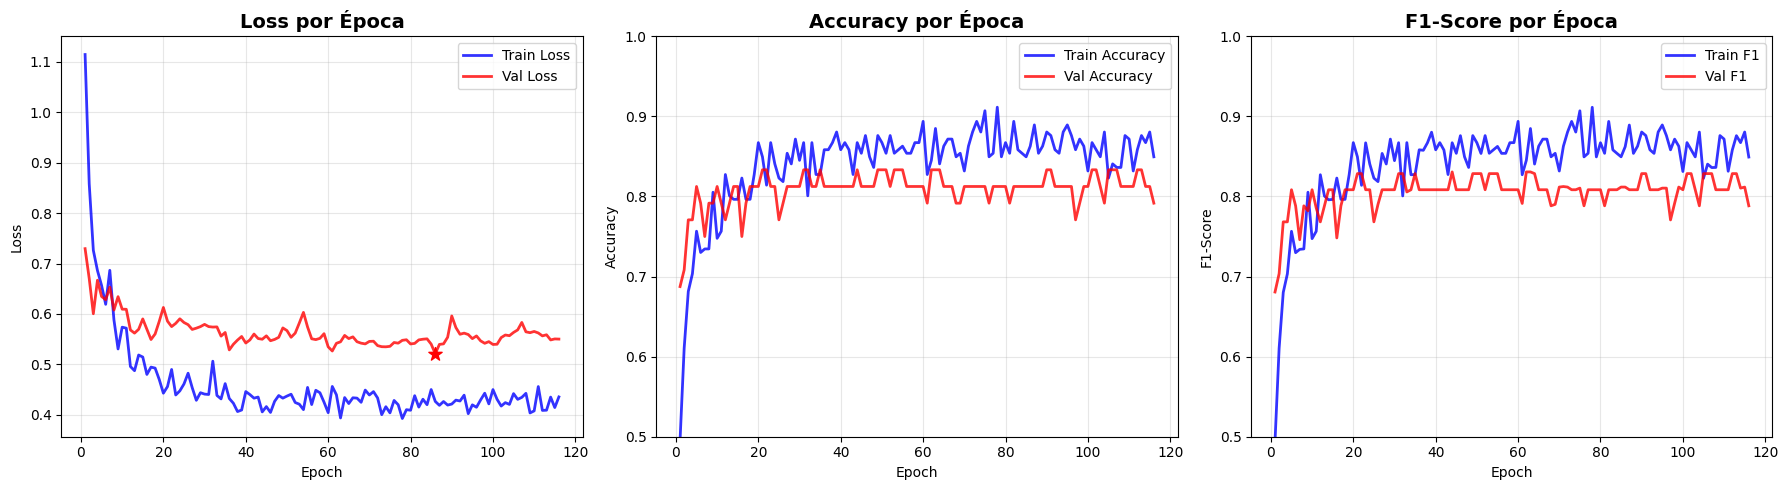


ANÁLISIS DETALLADO DE OVERFITTING

Métricas finales (última época):
  Train loss: 0.4357
  Val loss:   0.5503
  Gap:        0.1146

Métricas en el mejor modelo:
  Train loss: 0.4268
  Val loss:   0.5212
  Gap:        0.0944

Accuracy:
  Train acc: 0.8496
  Val acc:   0.7917
  Diferencia: 0.0579

DIAGNÓSTICO
⚠ MODERADO: Overfitting moderado (0.08 < gap < 0.12)
   Recomendación: Aumentar dropout a 0.7-0.8 o reducir arquitectura.

↓ El modelo aún estaba mejorando (considerar más épocas)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, alpha=0.8)
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2, alpha=0.8)
axes[0].set_title('Loss por Época', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Marcar el mínimo
min_val_loss_idx = np.argmin(history['val_loss'])
axes[0].scatter(min_val_loss_idx + 1, history['val_loss'][min_val_loss_idx], 
                color='red', s=100, zorder=5, marker='*', label='Best')

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2, alpha=0.8)
axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Accuracy', linewidth=2, alpha=0.8)
axes[1].set_title('Accuracy por Época', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.5, 1.0])

# F1-Score
axes[2].plot(epochs, history['train_f1'], 'b-', label='Train F1', linewidth=2, alpha=0.8)
axes[2].plot(epochs, history['val_f1'], 'r-', label='Val F1', linewidth=2, alpha=0.8)
axes[2].set_title('F1-Score por Época', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1-Score')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

# Análisis detallado de overfitting
final_train_loss = history['train_loss'][-1]
final_val_loss = history['val_loss'][-1]
best_train_loss = min(history['train_loss'])
best_val_loss = min(history['val_loss'])
gap_final = abs(final_val_loss - final_train_loss)
gap_best = abs(best_val_loss - history['train_loss'][np.argmin(history['val_loss'])])

print("\n" + "="*80)
print("ANÁLISIS DETALLADO DE OVERFITTING")
print("="*80)
print(f"\nMétricas finales (última época):")
print(f"  Train loss: {final_train_loss:.4f}")
print(f"  Val loss:   {final_val_loss:.4f}")
print(f"  Gap:        {gap_final:.4f}")

print(f"\nMétricas en el mejor modelo:")
print(f"  Train loss: {history['train_loss'][np.argmin(history['val_loss'])]:.4f}")
print(f"  Val loss:   {best_val_loss:.4f}")
print(f"  Gap:        {gap_best:.4f}")

print(f"\nAccuracy:")
print(f"  Train acc: {history['train_acc'][-1]:.4f}")
print(f"  Val acc:   {history['val_acc'][-1]:.4f}")
print(f"  Diferencia: {abs(history['train_acc'][-1] - history['val_acc'][-1]):.4f}")

print("\n" + "="*80)
print("DIAGNÓSTICO")
print("="*80)

if gap_best < 0.05:
    print("✅ EXCELENTE: Modelo bien ajustado (gap < 0.05)")
    print("   El modelo generaliza correctamente.")
elif gap_best < 0.08:
    print("✓ BUENO: Ligero overfitting aceptable (0.05 < gap < 0.08)")
    print("   Generalización buena, pero puede mejorarse.")
elif gap_best < 0.12:
    print("⚠ MODERADO: Overfitting moderado (0.08 < gap < 0.12)")
    print("   Recomendación: Aumentar dropout a 0.7-0.8 o reducir arquitectura.")
else:
    print("❌ CRÍTICO: Overfitting significativo (gap > 0.12)")
    print("   Acciones requeridas:")
    print("   1. Aumentar dropout a 0.7-0.8")
    print("   2. Reducir complejidad del modelo")
    print("   3. Aumentar weight_decay")
    print("   4. Considerar más datos o data augmentation adicional")

# Análisis de convergencia
if len(history['val_loss']) > 20:
    recent_val_losses = history['val_loss'][-10:]
    if max(recent_val_losses) - min(recent_val_losses) < 0.01:
        print("\n✓ El modelo convergió (val_loss estable en últimas 10 épocas)")
    elif history['val_loss'][-1] < history['val_loss'][-10]:
        print("\n↓ El modelo aún estaba mejorando (considerar más épocas)")
    else:
        print("\n↑ El modelo empeoró al final (early stopping funcionó correctamente)")

print("="*80)

## 12. EVALUACIÓN EN CONJUNTO DE PRUEBA

RESULTADOS EN TEST SET
Accuracy: 0.8333
F1-Score: 0.8333

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

 Present (0)     0.8333    0.8333    0.8333        24
  Absent (1)     0.8333    0.8333    0.8333        24

    accuracy                         0.8333        48
   macro avg     0.8333    0.8333    0.8333        48
weighted avg     0.8333    0.8333    0.8333        48



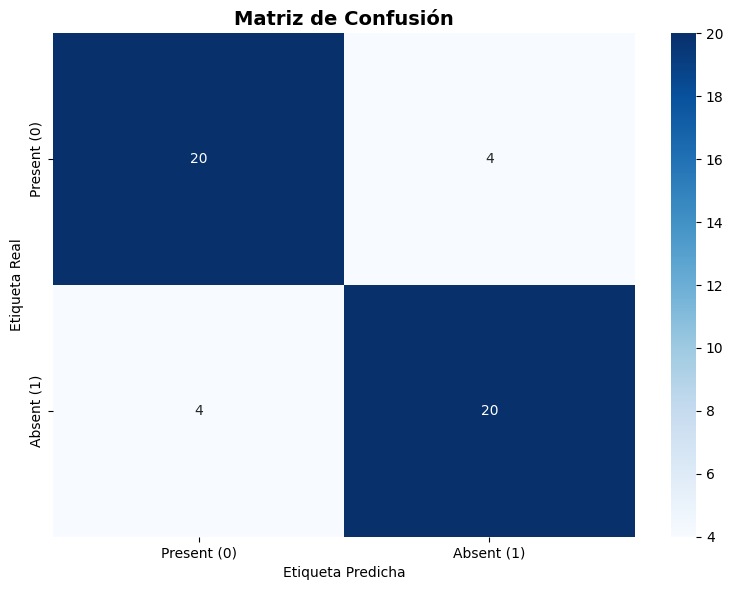

In [14]:
model_final.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_final(inputs)
        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='weighted')

print("="*60)
print("RESULTADOS EN TEST SET")
print("="*60)
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-Score: {test_f1:.4f}")

print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=['Present (0)', 'Absent (1)'], digits=4))

# Matriz de confusión
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Present (0)', 'Absent (1)'],
            yticklabels=['Present (0)', 'Absent (1)'])
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()